# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [1]:
import pandas as pd
import sklearn

![Iris Flowers](https://github.com/HassanAlgoz/B5/blob/main/content/W3/M1/assets/iris_flowers.png?raw=1)

### Step 1.a Load the data

In [2]:
iris = sklearn.datasets.load_iris(as_frame=True)

### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = iris.data
y = iris.target

### Step 2.b print the type of each

In [4]:
print("Type of X:", type(X))
print("Type of y:", type(y))

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

The target `y` is **categorical** (0, 1, 2 = three Iris species).
Therefore, the task is **classification**.

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [5]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Target class names: {iris.target_names.tolist()}")

X shape: (150, 4)
y shape: (150,)
Number of samples: 150
Number of features: 4
Target class names: ['setosa', 'versicolor', 'virginica']


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [6]:
X.agg(['min', 'max', 'median', 'mean', 'std']).round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
min,4.30,2.00,1.00,0.10
max,7.90,4.40,6.90,2.50
median,5.80,3.00,4.35,1.30
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76


### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

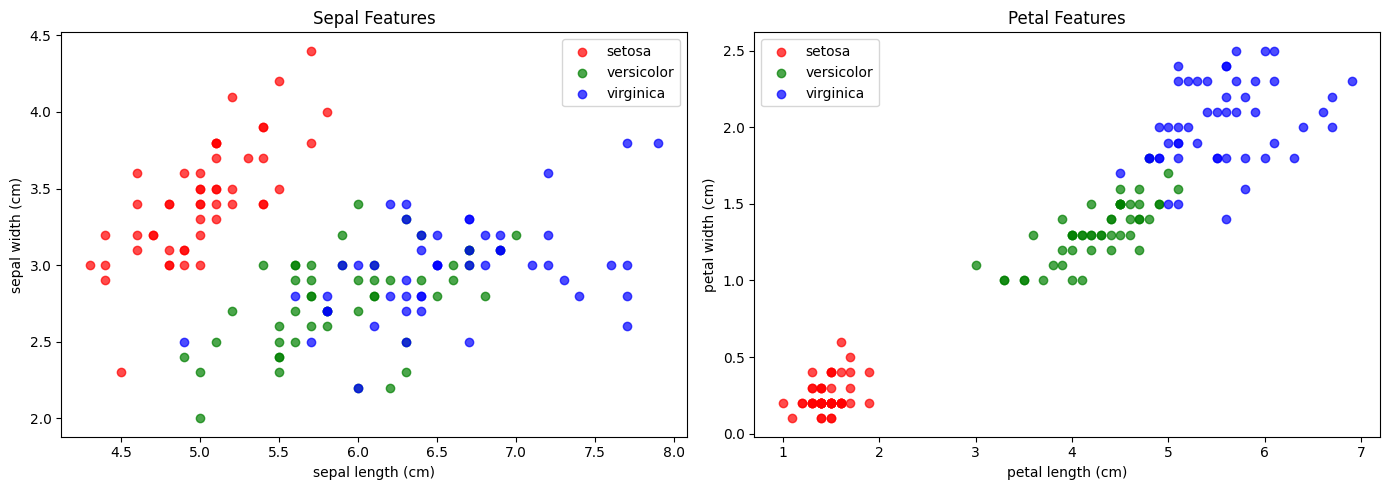

In [7]:
import matplotlib.pyplot as plt

colors = ['red', 'green', 'blue']
class_names = iris.target_names

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in range(3):
    mask = y == cls
    axes[0].scatter(X.loc[mask, 'sepal length (cm)'], X.loc[mask, 'sepal width (cm)'],
                    label=class_names[cls], color=colors[cls], alpha=0.7)
axes[0].set_xlabel('sepal length (cm)')
axes[0].set_ylabel('sepal width (cm)')
axes[0].set_title('Sepal Features')
axes[0].legend()

for cls in range(3):
    mask = y == cls
    axes[1].scatter(X.loc[mask, 'petal length (cm)'], X.loc[mask, 'petal width (cm)'],
                    label=class_names[cls], color=colors[cls], alpha=0.7)
axes[1].set_xlabel('petal length (cm)')
axes[1].set_ylabel('petal width (cm)')
axes[1].set_title('Petal Features')
axes[1].legend()

plt.tight_layout()
plt.show()

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [8]:
X_sepal = X[['sepal length (cm)', 'sepal width (cm)']]
X_sepal.head()

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [9]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]
X_petal.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


### Step 7. Initialize 2 `LogisticRegression` models

In [10]:
from sklearn.linear_model import LogisticRegression

model_sepal = LogisticRegression(max_iter=200)
model_petal = LogisticRegression(max_iter=200)

### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [11]:
from sklearn.model_selection import train_test_split

X_sepal_train, X_sepal_test, y_sepal_train, y_sepal_test = train_test_split(
    X_sepal, y, test_size=0.2, random_state=42, stratify=y
)

X_petal_train, X_petal_test, y_petal_train, y_petal_test = train_test_split(
    X_petal, y, test_size=0.2, random_state=42, stratify=y
)

print('Sepal train/test:', X_sepal_train.shape, X_sepal_test.shape)
print('Petal train/test:', X_petal_train.shape, X_petal_test.shape)

Sepal train/test: (120, 2) (30, 2)
Petal train/test: (120, 2) (30, 2)


### Step 9.a Train both models

In [12]:
model_sepal.fit(X_sepal_train, y_sepal_train)
model_petal.fit(X_petal_train, y_petal_train)
print('Both models trained.')

Both models trained.


### Step 10. Evaluate and compare both models

In [13]:
from sklearn.metrics import accuracy_score

sepal_acc = accuracy_score(y_sepal_test, model_sepal.predict(X_sepal_test))
petal_acc = accuracy_score(y_petal_test, model_petal.predict(X_petal_test))

print(f'Sepal model accuracy: {sepal_acc*100:.2f}%')
print(f'Petal model accuracy: {petal_acc*100:.2f}%')
print(f'Better model: {"Petal" if petal_acc > sepal_acc else "Sepal"}')

Sepal model accuracy: 73.33%
Petal model accuracy: 96.67%
Better model: Petal


### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

**Petal features** better distinguish Iris flowers.

The petal scatter plot shows clearly separated clusters, especially *setosa*. Sepal features overlap between *versicolor* and *virginica*. The higher petal model accuracy confirms this.

### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

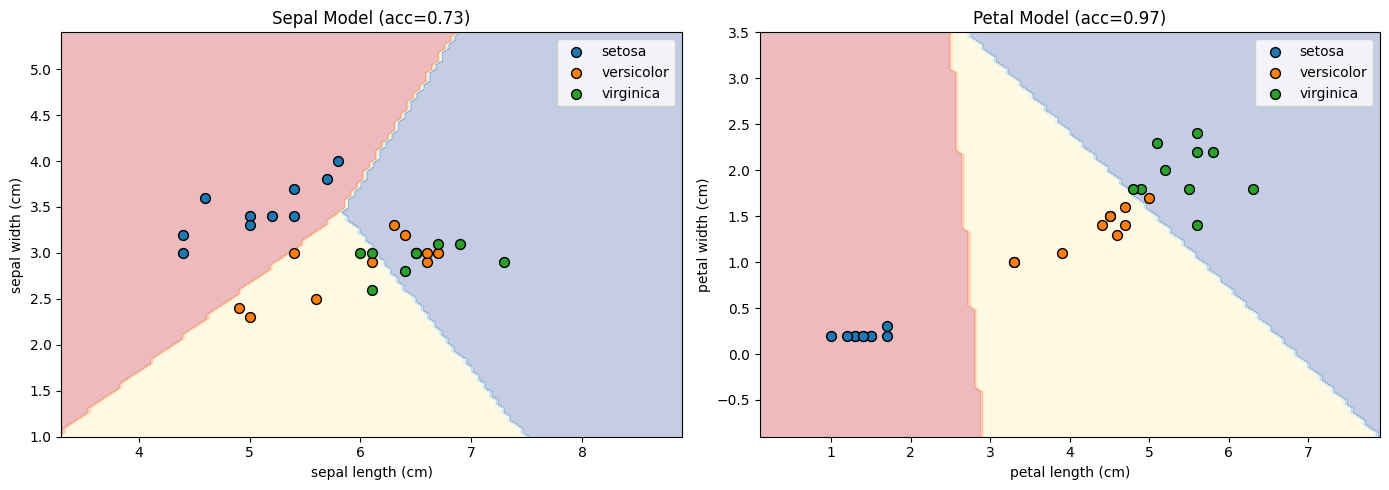

In [14]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

DecisionBoundaryDisplay.from_estimator(
    model_sepal, X_sepal_train, ax=axes[0],
    response_method='predict', alpha=0.3, cmap='RdYlBu'
)
for cls in range(3):
    mask = y_sepal_test == cls
    axes[0].scatter(
        X_sepal_test.loc[mask, 'sepal length (cm)'],
        X_sepal_test.loc[mask, 'sepal width (cm)'],
        label=class_names[cls], edgecolor='k', s=50
    )
axes[0].set_title(f'Sepal Model (acc={sepal_acc:.2f})')
axes[0].set_xlabel('sepal length (cm)')
axes[0].set_ylabel('sepal width (cm)')
axes[0].legend()

DecisionBoundaryDisplay.from_estimator(
    model_petal, X_petal_train, ax=axes[1],
    response_method='predict', alpha=0.3, cmap='RdYlBu'
)
for cls in range(3):
    mask = y_petal_test == cls
    axes[1].scatter(
        X_petal_test.loc[mask, 'petal length (cm)'],
        X_petal_test.loc[mask, 'petal width (cm)'],
        label=class_names[cls], edgecolor='k', s=50
    )
axes[1].set_title(f'Petal Model (acc={petal_acc:.2f})')
axes[1].set_xlabel('petal length (cm)')
axes[1].set_ylabel('petal width (cm)')
axes[1].legend()

plt.tight_layout()
plt.show()